# PatchTST v2 — Multi-CSV + horizon 10
**Modèle** : `ibm-granite/granite-timeseries-patchtst`  
**Données** : tous les CSV de `MegaDonneIA/StockTiny/`  
**Nouveautés** : déduplication, normalisation par actif, prediction_length=10

In [1]:
# =====================
# 1. Imports
# =====================
import os
import glob
import math
import pickle

import pandas as pd
import numpy as np
import torch
from transformers import PatchTSTForPrediction
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

print('Imports OK')

c:\Users\redwa\Documents\projetMegaDonnée\tsfm_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


In [2]:
# =====================
# 2. GPU
# =====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : NVIDIA GeForce RTX 3060


In [3]:
# =====================
# 3. Hyperparamètres
# =====================
CONTEXT_LENGTH    = 64
PREDICTION_LENGTH = 10
BATCH_SIZE        = 32
EPOCHS            = 20
LR_MAX            = 1e-3
TRAIN_RATIO       = 0.8
DATA_DIR          = 'MegaDonneIA/StockTiny/'   # <-- dossier avec tes CSV
SAVE_DIR          = './patchtst_saved'          # <-- où sauvegarder le modèle

In [23]:
# =====================
# 4. Chargement multi-CSV + déduplication
# =====================
# Chaque CSV est normalisé indépendamment (son propre scaler)
# pour éviter que les différences d'échelle entre actifs biaisent l'entraînement.
# Les fenêtres de tous les actifs sont ensuite concaténées.

def make_windows(data, ctx_len, pred_len):
    """Crée les fenêtres glissantes (X, y) depuis un array 2D (N, 1)."""
    X, y = [], []
    for i in range(len(data) - ctx_len - pred_len):
        X.append(data[i : i + ctx_len])
        y.append(data[i + ctx_len : i + ctx_len + pred_len])
    return np.array(X), np.array(y)


csv_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f'{len(csv_files)} fichiers CSV trouvés\n')

all_X_train, all_y_train = [], []
all_X_test,  all_y_test  = [], []
scalers = {}   # on garde les scalers pour la dénorm et l'inférence future
skipped = []

for path in csv_files:
    name = os.path.splitext(os.path.basename(path))[0]
    try:
        df = pd.read_csv(path)
        df = df.sort_values('date')

        # -- Déduplication --
        before = len(df)
        df = df.drop_duplicates(subset=['date'])
        removed = before - len(df)

        df.reset_index(drop=True, inplace=True)
        values = df[['close']].values.astype(np.float32)

        # Trop peu de points pour au moins 1 fenêtre train + test
        min_points = int((CONTEXT_LENGTH + PREDICTION_LENGTH) / TRAIN_RATIO * 1.1)
        if len(values) < min_points:
            skipped.append(name)
            continue

        # -- Split avant normalisation (pas de data leakage) --
        split = int(TRAIN_RATIO * len(values))
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(values[:split])
        test_scaled  = scaler.transform(values[split:])
        scalers[name] = scaler

        # -- Fenêtres --
        X_tr, y_tr = make_windows(train_scaled, CONTEXT_LENGTH, PREDICTION_LENGTH)
        X_te, y_te = make_windows(test_scaled,  CONTEXT_LENGTH, PREDICTION_LENGTH)

        if len(X_tr) == 0 or len(X_te) == 0:
            skipped.append(name)
            continue

        all_X_train.append(X_tr)
        all_y_train.append(y_tr)
        all_X_test.append(X_te)
        all_y_test.append(y_te)

        print(f'  {name:10s}  {len(df):6d} pts  ({removed} doublons supprimés)  '
              f'train={len(X_tr)}  test={len(X_te)}')

    except Exception as e:
        skipped.append(name)
        print(f'  {name}: ERREUR — {e}')

if skipped:
    print(f'\nFichiers ignorés (trop courts ou erreur) : {skipped}')

# -- Concaténation --
X_train = torch.tensor(np.concatenate(all_X_train, axis=0))  # (N, ctx, 1)
y_train = torch.tensor(np.concatenate(all_y_train, axis=0))  # (N, pred, 1)
X_test  = torch.tensor(np.concatenate(all_X_test,  axis=0))
y_test  = torch.tensor(np.concatenate(all_y_test,  axis=0))

print(f'\nTotal X_train : {X_train.shape}')
print(f'Total X_test  : {X_test.shape}')

10 fichiers CSV trouvés

  ABT          60398 pts  (59674 doublons supprimés)  train=48244  test=12006
  ACN          60869 pts  (60061 doublons supprimés)  train=48621  test=12100
  ADP          53407 pts  (52875 doublons supprimés)  train=42651  test=10608
  ALL          52426 pts  (51870 doublons supprimés)  train=41866  test=10412
  AON          51714 pts  (51200 doublons supprimés)  train=41297  test=10269
  CVX          77368 pts  (76425 doublons supprimés)  train=61820  test=15400
  D            57550 pts  (56900 doublons supprimés)  train=45966  test=11436
  DAL          78671 pts  (77816 doublons supprimés)  train=62862  test=15661
  DASH         62957 pts  (62252 doublons supprimés)  train=50291  test=12518
  DAY          38039 pts  (37574 doublons supprimés)  train=30357  test=7534

Total X_train : torch.Size([473975, 64, 1])
Total X_test  : torch.Size([117944, 64, 1])


In [24]:
# =====================
# 5. Envoi sur GPU
# =====================
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test  = X_test.to(device)
y_test  = y_test.to(device)
print(f'Tenseurs sur : {X_train.device}')

Tenseurs sur : cuda:0


In [25]:
# =====================
# 6. Chargement du modèle PatchTST
# =====================
model = PatchTSTForPrediction.from_pretrained(
    'ibm-granite/granite-timeseries-patchtst',
    num_input_channels=1,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    ignore_mismatched_sizes=True
)
model = model.to(device)
model.train()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres entraînables : {total_params:,}')

Loading weights: 100%|██████████| 72/72 [00:00<00:00, 1043.47it/s, Materializing param=model.encoder.positional_encoder.position_enc]                      
PatchTSTForPrediction LOAD REPORT from: ibm-granite/granite-timeseries-patchtst
Key                                           | Status   |                                                                                       
----------------------------------------------+----------+---------------------------------------------------------------------------------------
head.projection.weight                        | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([96, 128]) vs model:torch.Size([10, 128])
model.encoder.positional_encoder.position_enc | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([43, 128]) vs model:torch.Size([6, 128]) 
head.projection.bias                          | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([96]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights w

Paramètres entraînables : 598,666


In [26]:
# =====================
# 7. Entraînement
# =====================
optimizer = torch.optim.AdamW(model.parameters(), lr=LR_MAX)
loss_fn   = torch.nn.MSELoss()

steps_per_epoch = math.ceil(len(X_train) / BATCH_SIZE)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR_MAX,
    total_steps=steps_per_epoch * EPOCHS,
    pct_start=0.3
)

history = []

for epoch in range(EPOCHS):
    model.train()
    perm       = torch.randperm(len(X_train))
    total_loss = 0.0
    n_batches  = 0

    for i in range(0, len(X_train), BATCH_SIZE):
        idx     = perm[i : i + BATCH_SIZE]
        batch_x = X_train[idx]
        batch_y = y_train[idx]

        optimizer.zero_grad()
        outputs = model(past_values=batch_x)
        preds   = outputs.prediction_outputs  # (B, pred_len, 1)
        loss    = loss_fn(preds, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        n_batches  += 1

    avg_loss = total_loss / n_batches
    history.append(avg_loss)
    print(f'Epoch {epoch+1:02d}/{EPOCHS} – Loss: {avg_loss:.6f}  LR: {scheduler.get_last_lr()[0]:.2e}')

Epoch 01/20 – Loss: 0.005792  LR: 1.04e-04
Epoch 02/20 – Loss: 0.005850  LR: 2.80e-04
Epoch 03/20 – Loss: 0.005841  LR: 5.20e-04
Epoch 04/20 – Loss: 0.006114  LR: 7.60e-04
Epoch 05/20 – Loss: 0.006091  LR: 9.36e-04
Epoch 06/20 – Loss: 0.005992  LR: 1.00e-03
Epoch 07/20 – Loss: 0.005933  LR: 9.87e-04
Epoch 08/20 – Loss: 0.005830  LR: 9.50e-04
Epoch 09/20 – Loss: 0.005857  LR: 8.91e-04
Epoch 10/20 – Loss: 0.005696  LR: 8.12e-04
Epoch 11/20 – Loss: 0.005575  LR: 7.17e-04
Epoch 12/20 – Loss: 0.005560  LR: 6.11e-04
Epoch 13/20 – Loss: 0.005483  LR: 5.00e-04
Epoch 14/20 – Loss: 0.005388  LR: 3.89e-04
Epoch 15/20 – Loss: 0.005258  LR: 2.83e-04
Epoch 16/20 – Loss: 0.005201  LR: 1.88e-04
Epoch 17/20 – Loss: 0.005130  LR: 1.09e-04
Epoch 18/20 – Loss: 0.005064  LR: 4.95e-05
Epoch 19/20 – Loss: 0.005031  LR: 1.25e-05
Epoch 20/20 – Loss: 0.004986  LR: 4.00e-09


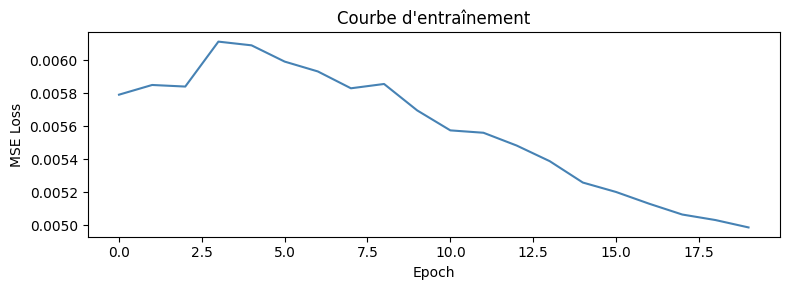

In [27]:
# =====================
# 8. Courbe de loss
# =====================
plt.figure(figsize=(8, 3))
plt.plot(history, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title("Courbe d'entraînement")
plt.tight_layout()
plt.show()

In [28]:
# =====================
# 9. Évaluation globale
# =====================
model.eval()
with torch.no_grad():
    outputs   = model(past_values=X_test)
    preds_all = outputs.prediction_outputs  # (N, pred_len, 1)

preds_np  = preds_all.cpu().numpy()   # (N, pred_len, 1)
y_test_np = y_test.cpu().numpy()

# Métriques en espace normalisé (comparables entre actifs)
mae_norm  = mean_absolute_error(y_test_np.reshape(-1), preds_np.reshape(-1))
rmse_norm = np.sqrt(mean_squared_error(y_test_np.reshape(-1), preds_np.reshape(-1)))

# Baseline naïve normalisée : répéter le dernier point de X_test comme prédiction
last_known = X_test.cpu().numpy()[:, -1, :]          # (N, 1)
naive_pred = np.repeat(last_known[:, np.newaxis, :], PREDICTION_LENGTH, axis=1)  # (N, pred_len, 1)
mae_naive  = mean_absolute_error(y_test_np.reshape(-1), naive_pred.reshape(-1))
rmse_naive = np.sqrt(mean_squared_error(y_test_np.reshape(-1), naive_pred.reshape(-1)))

print('=== Métriques globales (espace normalisé) ===')
print(f'MAE  modèle : {mae_norm:.4f}  |  MAE  naïf : {mae_naive:.4f}')
print(f'RMSE modèle : {rmse_norm:.4f}  |  RMSE naïf : {rmse_naive:.4f}')
print()
if mae_norm < mae_naive:
    print('✅ Le modèle bat la baseline naïve')
else:
    print('⚠️  Le modèle ne bat pas encore la baseline naïve')

=== Métriques globales (espace normalisé) ===
MAE  modèle : 0.0204  |  MAE  naïf : 0.0200
RMSE modèle : 0.0355  |  RMSE naïf : 0.0342

⚠️  Le modèle ne bat pas encore la baseline naïve


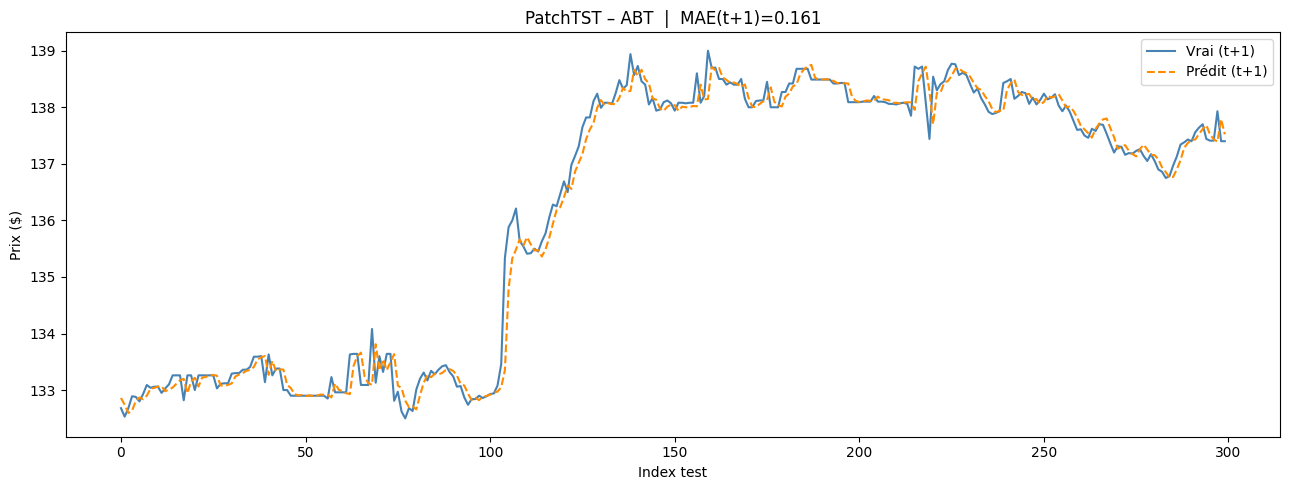

In [29]:
# =====================
# 10. Visualisation sur un actif précis
# =====================
# On re-évalue sur le premier actif du dossier pour avoir une dénorm propre.

ACTIF_VIZ = list(scalers.keys())[0]   # change ici si tu veux un actif spécifique
scaler_viz = scalers[ACTIF_VIZ]

# Recharge le CSV de cet actif pour reconstruire ses fenêtres de test
df_viz = pd.read_csv(os.path.join(DATA_DIR, ACTIF_VIZ + '.csv'))
df_viz = df_viz.sort_values('date').drop_duplicates(subset=['date']).reset_index(drop=True)
vals_viz   = df_viz[['close']].values.astype(np.float32)
split_viz  = int(TRAIN_RATIO * len(vals_viz))
test_scaled_viz = scaler_viz.transform(vals_viz[split_viz:])

X_viz_np, y_viz_np = make_windows(test_scaled_viz, CONTEXT_LENGTH, PREDICTION_LENGTH)
X_viz = torch.tensor(X_viz_np).to(device)

model.eval()
with torch.no_grad():
    preds_viz = model(past_values=X_viz).prediction_outputs.cpu().numpy()

# Dénorm : on prend le premier pas de chaque fenêtre pour tracer une courbe continue
pred_step0  = scaler_viz.inverse_transform(preds_viz[:, 0, :])   # 1er pas prédit
true_step0  = scaler_viz.inverse_transform(y_viz_np[:, 0, :])    # 1er pas réel

n_plot = min(300, len(pred_step0))
plt.figure(figsize=(13, 5))
plt.plot(true_step0[:n_plot],  label='Vrai (t+1)',    color='steelblue',  linewidth=1.5)
plt.plot(pred_step0[:n_plot],  label='Prédit (t+1)',  color='darkorange', linewidth=1.5, linestyle='--')
mae_viz = mean_absolute_error(true_step0[:n_plot], pred_step0[:n_plot])
plt.title(f'PatchTST – {ACTIF_VIZ}  |  MAE(t+1)={mae_viz:.3f}')
plt.xlabel('Index test')
plt.ylabel('Prix ($)')
plt.legend()
plt.tight_layout()
plt.show()

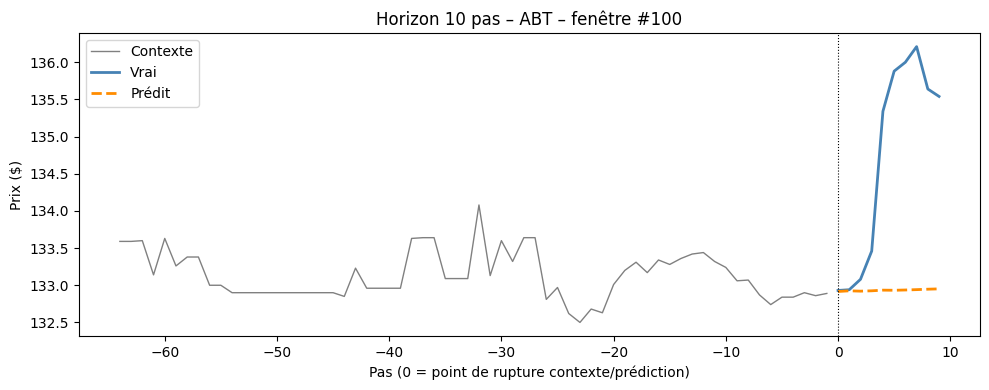

In [30]:
# =====================
# 11. Visualisation de l'horizon complet (fan chart)
# =====================
# On prend un seul exemple de test et on trace les 10 pas prédits vs réels.

IDX = 100   # fenêtre de test à visualiser — change si tu veux

pred_ex = scaler_viz.inverse_transform(preds_viz[IDX])   # (pred_len, 1)
true_ex = scaler_viz.inverse_transform(y_viz_np[IDX])    # (pred_len, 1)
ctx_ex  = scaler_viz.inverse_transform(X_viz_np[IDX])    # (ctx_len, 1)

x_ctx  = np.arange(-CONTEXT_LENGTH, 0)
x_pred = np.arange(0, PREDICTION_LENGTH)

plt.figure(figsize=(10, 4))
plt.plot(x_ctx,  ctx_ex.squeeze(),  color='gray',        linewidth=1,   label='Contexte')
plt.plot(x_pred, true_ex.squeeze(), color='steelblue',   linewidth=2,   label='Vrai')
plt.plot(x_pred, pred_ex.squeeze(), color='darkorange',  linewidth=2,   linestyle='--', label='Prédit')
plt.axvline(0, color='black', linewidth=0.8, linestyle=':')
plt.title(f'Horizon 10 pas – {ACTIF_VIZ} – fenêtre #{IDX}')
plt.xlabel('Pas (0 = point de rupture contexte/prédiction)')
plt.ylabel('Prix ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# =====================
# 12. Sauvegarde du modèle + scalers
# =====================
os.makedirs(SAVE_DIR, exist_ok=True)

# Modèle
model.save_pretrained(SAVE_DIR)

# Scalers (un par actif — nécessaires pour dénormaliser en inférence)
with open(os.path.join(SAVE_DIR, 'scalers.pkl'), 'wb') as f:
    pickle.dump(scalers, f)

# Config de base utile pour l'API
import json
cfg = {
    'context_length':    CONTEXT_LENGTH,
    'prediction_length': PREDICTION_LENGTH,
    'num_input_channels': 1
}
with open(os.path.join(SAVE_DIR, 'inference_config.json'), 'w') as f:
    json.dump(cfg, f, indent=2)

print(f'Modèle sauvegardé dans : {SAVE_DIR}/')
print(f'  config.json  (poids HuggingFace)')
print(f'  scalers.pkl  ({len(scalers)} actifs)')
print(f'  inference_config.json')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 124.98it/s]

Modèle sauvegardé dans : ./patchtst_saved/
  config.json  (poids HuggingFace)
  scalers.pkl  (10 actifs)
  inference_config.json


In [14]:
# =====================
# 13. Inférence future — exemple sur un actif
# =====================
# Prédit les 10 prochains pas à partir des derniers points connus.

ACTIF_INFER = list(scalers.keys())[0]   # change ici
scaler_infer = scalers[ACTIF_INFER]

df_infer = pd.read_csv(os.path.join(DATA_DIR, ACTIF_INFER + '.csv'))
df_infer = df_infer.sort_values('date').drop_duplicates(subset=['date']).reset_index(drop=True)
vals_infer = df_infer[['close']].values.astype(np.float32)

last_ctx = scaler_infer.transform(vals_infer[-CONTEXT_LENGTH:])           # (64, 1)
last_ctx_t = torch.tensor(last_ctx).unsqueeze(0).to(device)               # (1, 64, 1)

model.eval()
with torch.no_grad():
    future = model(past_values=last_ctx_t).prediction_outputs             # (1, 10, 1)

future_denorm = scaler_infer.inverse_transform(future.cpu().squeeze(0).numpy())  # (10, 1)

print(f'Actif        : {ACTIF_INFER}')
print(f'Dernier close: {vals_infer[-1][0]:.4f}')
print(f'Prédictions 10 pas :')
for i, v in enumerate(future_denorm.squeeze(), start=1):
    print(f'  t+{i:02d} : {v:.4f}')

Actif        : ABT
Dernier close: 126.8500
Prédictions 10 pas :
  t+01 : 126.8643
  t+02 : 126.8547
  t+03 : 126.8468
  t+04 : 126.8416
  t+05 : 126.8383
  t+06 : 126.8371
  t+07 : 126.8371
  t+08 : 126.8357
  t+09 : 126.8346
  t+10 : 126.8359
